<a href="https://colab.research.google.com/github/mb8721/Robs/blob/main/PupperLimpingDog_Sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐕 Pupper Limping-Dog Gait — MuJoCo Simulation

Tune the **limping-dog gait** in simulation **before** deploying to the real Pupper. Each iteration takes ~30 seconds in sim vs ~10 minutes on the real robot.

**Strategy:**
- HL is hardcoded as the disabled leg, tucked tight at `(-0.04, +0.04, -0.04)`
- Front pair (FR + FL) moves as ONE unit (same x command at every step)
- HR moves separately
- Body held LOWER than nominal for stability (z = -0.10)
- 90% of every cycle has all 3 active feet planted

**Cells:**
1. Install MuJoCo
2. Inline simplified Pupper MJCF (no GitHub clone needed)
3. MuJoCo-based IK (uses sim's actual kinematics → guaranteed foot positions)
4. Gait controller (same code that runs on the real Pupper)
5. Metrics logger (same J / S formulas as real robot)
6. MuJoCoBridge (replaces the ROS bridge)
7. Single trial with video
8. All conditions × N trials → CSV

> **Sim vs real:** the controller's output is **foot positions in body frame**. Both real robot and sim run their own IK to convert these to joint angles. So gait parameters that work in sim (step length, swing height, body height, swing windows) **do transfer** to the real robot. The internal joint angles will differ — that's fine.


In [1]:
# ---- 1. Install + setup rendering ----
# CRITICAL: MUJOCO_GL must be set BEFORE the first `import mujoco`.
# This cell does NOT re-import mujoco. If EGL fails, switch to GPU runtime.

import os
os.environ["MUJOCO_GL"] = "egl"

import subprocess, sys
print("Installing MuJoCo + mediapy...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "mujoco==3.1.6", "mediapy"], check=True)

import mujoco, numpy as np, scipy.optimize, mediapy, time as time_mod, csv

# Test rendering
try:
    _m = mujoco.MjModel.from_xml_string("<mujoco/>")
    _d = mujoco.MjData(_m)
    _r = mujoco.Renderer(_m, 64, 64)
    _r.update_scene(_d); _r.render(); _r.close()
    print(f"✓ MuJoCo {mujoco.__version__} | EGL rendering works")
except Exception as e:
    print(f"\n✗ EGL rendering failed: {e}\n")
    print("FIX: Runtime → Change runtime type → T4 GPU")
    print("Then: Runtime → Disconnect and delete runtime")
    print("Then: Runtime → Run all")
    raise


Installing MuJoCo + mediapy...
✓ MuJoCo 3.1.6 | EGL rendering works


## Cell 2 — Pupper-shaped MJCF (self-contained)

In [2]:
# ---- 2. Pupper-shaped quadruped MJCF ----
# Self-contained: no GitHub clone needed in Colab.
# Dimensions match Stanford Pupper v3:
#   * Trunk: ~20cm long, 12cm wide, 5cm tall
#   * Hip offsets: front ±0.0835, back ±0.0725 in y
#   * Shoulders at x = ±0.075
#   * Leg total length ~14cm (upper 7cm + lower 7cm)
#
# Joints are axis-aligned (joint 1 = X for hip abduction, joints 2/3 = Y for swing/knee).
# This is SIMPLER than Lab 3's exact kinematic chain — and that's fine because we use
# MuJoCo-based IK that respects whatever MJCF kinematics we have.

PUPPER_XML = '''
<mujoco model="pupper_v3_sim">
  <option timestep="0.002" iterations="20" solver="Newton" tolerance="1e-10"
          gravity="0 0 -9.81"/>

  <visual>
    <headlight diffuse="0.8 0.8 0.8" ambient="0.3 0.3 0.3"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="120" elevation="-20"/>
  </visual>

  <default>
    <joint armature="0.01" damping="0.5" frictionloss="0.02"/>
    <geom contype="1" conaffinity="1" friction="1.2 0.05 0.05"/>
    <position kp="35" forcerange="-3 3" ctrlrange="-3.14 3.14"/>
  </default>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1=".3 .5 .7" rgb2="0 0 0" width="32" height="512"/>
    <texture name="grid" type="2d" builtin="checker" rgb1=".15 .25 .35" rgb2=".25 .35 .45"
             width="300" height="300" mark="edge" markrgb=".4 .4 .4"/>
    <material name="grid" texture="grid" texrepeat="20 20" texuniform="true" reflectance="0.2"/>
  </asset>

  <worldbody>
    <light pos="0 0 3" dir="0 0 -1" diffuse="0.7 0.7 0.7"/>
    <geom name="floor" type="plane" size="3 3 0.1" material="grid" friction="1.2 0.05 0.05"/>

    <body name="trunk" pos="0 0 0.16">
      <freejoint/>
      <inertial pos="0.005 0 0" mass="0.7" diaginertia="0.005 0.012 0.012"/>
      <geom name="trunk_geom" type="box" size="0.10 0.06 0.025" rgba="0.25 0.30 0.55 1" mass="0"/>
      <site name="imu" pos="0 0 0" size="0.005"/>

      <!-- ============================ FR leg ============================ -->
      <body name="hip_fr" pos="0.075 -0.0835 0">
        <joint name="leg_front_r_1" axis="1 0 0" range="-1.5 1.5"/>
        <geom type="capsule" fromto="0 0 0 0 -0.025 0" size="0.012" rgba="0.2 0.2 0.2 1" mass="0.05"/>
        <body name="upper_fr" pos="0 -0.025 0">
          <joint name="leg_front_r_2" axis="0 1 0" range="-2.5 2.5"/>
          <geom type="capsule" fromto="0 0 0 0 0 -0.07" size="0.011" rgba="0.45 0.45 0.45 1" mass="0.04"/>
          <body name="lower_fr" pos="0 0 -0.07">
            <joint name="leg_front_r_3" axis="0 1 0" range="-2.5 2.5"/>
            <geom type="capsule" fromto="0 0 0 0 0 -0.07" size="0.009" rgba="0.55 0.55 0.55 1" mass="0.03"/>
            <body name="foot_fr" pos="0 0 -0.07">
              <geom type="sphere" size="0.013" rgba="0.1 0.1 0.1 1" mass="0.01" friction="1.5 0.05 0.05"/>
            </body>
          </body>
        </body>
      </body>

      <!-- ============================ FL leg ============================ -->
      <body name="hip_fl" pos="0.075 0.0835 0">
        <joint name="leg_front_l_1" axis="1 0 0" range="-1.5 1.5"/>
        <geom type="capsule" fromto="0 0 0 0 0.025 0" size="0.012" rgba="0.2 0.2 0.2 1" mass="0.05"/>
        <body name="upper_fl" pos="0 0.025 0">
          <joint name="leg_front_l_2" axis="0 1 0" range="-2.5 2.5"/>
          <geom type="capsule" fromto="0 0 0 0 0 -0.07" size="0.011" rgba="0.45 0.45 0.45 1" mass="0.04"/>
          <body name="lower_fl" pos="0 0 -0.07">
            <joint name="leg_front_l_3" axis="0 1 0" range="-2.5 2.5"/>
            <geom type="capsule" fromto="0 0 0 0 0 -0.07" size="0.009" rgba="0.55 0.55 0.55 1" mass="0.03"/>
            <body name="foot_fl" pos="0 0 -0.07">
              <geom type="sphere" size="0.013" rgba="0.1 0.1 0.1 1" mass="0.01" friction="1.5 0.05 0.05"/>
            </body>
          </body>
        </body>
      </body>

      <!-- ============================ BR (HR) leg ============================ -->
      <body name="hip_br" pos="-0.075 -0.0725 0">
        <joint name="leg_back_r_1" axis="1 0 0" range="-1.5 1.5"/>
        <geom type="capsule" fromto="0 0 0 0 -0.025 0" size="0.012" rgba="0.2 0.2 0.2 1" mass="0.05"/>
        <body name="upper_br" pos="0 -0.025 0">
          <joint name="leg_back_r_2" axis="0 1 0" range="-2.5 2.5"/>
          <geom type="capsule" fromto="0 0 0 0 0 -0.07" size="0.011" rgba="0.45 0.45 0.45 1" mass="0.04"/>
          <body name="lower_br" pos="0 0 -0.07">
            <joint name="leg_back_r_3" axis="0 1 0" range="-2.5 2.5"/>
            <geom type="capsule" fromto="0 0 0 0 0 -0.07" size="0.009" rgba="0.55 0.55 0.55 1" mass="0.03"/>
            <body name="foot_br" pos="0 0 -0.07">
              <geom type="sphere" size="0.013" rgba="0.1 0.1 0.1 1" mass="0.01" friction="1.5 0.05 0.05"/>
            </body>
          </body>
        </body>
      </body>

      <!-- ============================ BL (HL) leg — RED = "broken" leg ============================ -->
      <body name="hip_bl" pos="-0.075 0.0725 0">
        <joint name="leg_back_l_1" axis="1 0 0" range="-1.5 1.5"/>
        <geom type="capsule" fromto="0 0 0 0 0.025 0" size="0.012" rgba="0.9 0.1 0.1 1" mass="0.05"/>
        <body name="upper_bl" pos="0 0.025 0">
          <joint name="leg_back_l_2" axis="0 1 0" range="-2.5 2.5"/>
          <geom type="capsule" fromto="0 0 0 0 0 -0.07" size="0.011" rgba="0.95 0.2 0.2 1" mass="0.04"/>
          <body name="lower_bl" pos="0 0 -0.07">
            <joint name="leg_back_l_3" axis="0 1 0" range="-2.5 2.5"/>
            <geom type="capsule" fromto="0 0 0 0 0 -0.07" size="0.009" rgba="0.95 0.3 0.3 1" mass="0.03"/>
            <body name="foot_bl" pos="0 0 -0.07">
              <geom type="sphere" size="0.013" rgba="0.7 0.05 0.05 1" mass="0.01" friction="1.5 0.05 0.05"/>
            </body>
          </body>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <position name="act_fr1" joint="leg_front_r_1"/>
    <position name="act_fr2" joint="leg_front_r_2"/>
    <position name="act_fr3" joint="leg_front_r_3"/>
    <position name="act_fl1" joint="leg_front_l_1"/>
    <position name="act_fl2" joint="leg_front_l_2"/>
    <position name="act_fl3" joint="leg_front_l_3"/>
    <position name="act_br1" joint="leg_back_r_1"/>
    <position name="act_br2" joint="leg_back_r_2"/>
    <position name="act_br3" joint="leg_back_r_3"/>
    <position name="act_bl1" joint="leg_back_l_1"/>
    <position name="act_bl2" joint="leg_back_l_2"/>
    <position name="act_bl3" joint="leg_back_l_3"/>
  </actuator>

  <sensor>
    <framequat name="orientation" objtype="site" objname="imu"/>
    <gyro name="gyro" site="imu"/>
    <accelerometer name="accel" site="imu"/>
  </sensor>
</mujoco>
'''

with open("/tmp/pupper.xml", "w") as f:
    f.write(PUPPER_XML)

model = mujoco.MjModel.from_xml_path("/tmp/pupper.xml")
data  = mujoco.MjData(model)
print(f"Model loaded: {model.njnt} joints, {model.nu} actuators, {model.nbody} bodies")


Model loaded: 13 joints, 12 actuators, 18 bodies


## Cell 3 — MuJoCo-based IK

Uses MuJoCo's actual kinematics. Foot positions in sim are **guaranteed** to match what the controller asks for.

In [3]:
# ---- 3. MuJoCo-based IK ----
# Uses MuJoCo's actual kinematics. When this IK gives joint angles back,
# applying them to MuJoCo will put the foot exactly where commanded.

JOINT_NAMES_MJ = [
    "leg_front_r_1", "leg_front_r_2", "leg_front_r_3",
    "leg_front_l_1", "leg_front_l_2", "leg_front_l_3",
    "leg_back_r_1",  "leg_back_r_2",  "leg_back_r_3",
    "leg_back_l_1",  "leg_back_l_2",  "leg_back_l_3",
]
ACTUATOR_NAMES_MJ = [
    "act_fr1","act_fr2","act_fr3","act_fl1","act_fl2","act_fl3",
    "act_br1","act_br2","act_br3","act_bl1","act_bl2","act_bl3",
]
FOOT_BODY_NAMES = ["foot_fr", "foot_fl", "foot_br", "foot_bl"]


def _quat_to_rot_inv(quat):
    """Inverse rotation matrix from MuJoCo quaternion (w, x, y, z)."""
    w, x, y, z = quat
    return np.array([
        [1 - 2*(y*y + z*z),  2*(x*y + z*w),      2*(x*z - y*w)],
        [2*(x*y - z*w),      1 - 2*(x*x + z*z),  2*(y*z + x*w)],
        [2*(x*z + y*w),      2*(y*z - x*w),      1 - 2*(x*x + y*y)],
    ])


def mj_ik_single_leg(target_in_body_frame, leg_idx, x0, model, data):
    """IK: returns joint angles such that foot[leg_idx] is at target in trunk's local frame."""
    foot_id   = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, FOOT_BODY_NAMES[leg_idx])
    trunk_id  = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "trunk")

    joint_addrs = []
    for j in range(3):
        jname = JOINT_NAMES_MJ[3*leg_idx + j]
        jid   = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, jname)
        joint_addrs.append(model.jnt_qposadr[jid])

    saved_qpos = data.qpos.copy()

    def err(theta):
        for j in range(3):
            data.qpos[joint_addrs[j]] = theta[j]
        mujoco.mj_kinematics(model, data)
        foot_world  = data.xpos[foot_id]
        trunk_world = data.xpos[trunk_id]
        trunk_quat  = data.xquat[trunk_id]
        # Foot in trunk's local frame
        diff_world = foot_world - trunk_world
        Rt = _quat_to_rot_inv(trunk_quat)
        foot_body = Rt @ diff_world
        return np.linalg.norm(foot_body - np.asarray(target_in_body_frame))

    res = scipy.optimize.minimize(
        err, x0=np.asarray(x0, dtype=float),
        method="L-BFGS-B", bounds=[(-3.0, 3.0)] * 3,
        options={"maxiter": 30, "ftol": 1e-9},
    )

    # Restore state
    data.qpos[:] = saved_qpos
    mujoco.mj_kinematics(model, data)
    return res.x


# Sanity check: IK round-trip on FR foot at default stance position
target = np.array([0.06, -0.09, -0.10])
mujoco.mj_resetData(model, data)
data.qpos[2] = 0.16
mujoco.mj_kinematics(model, data)
theta = mj_ik_single_leg(target, 0, [0, 0.7, -1.4], model, data)

# Apply theta and verify
joint_addrs_fr = [model.jnt_qposadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n)]
                  for n in JOINT_NAMES_MJ[:3]]
for j, addr in enumerate(joint_addrs_fr):
    data.qpos[addr] = theta[j]
mujoco.mj_kinematics(model, data)
foot_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "foot_fr")
trunk_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "trunk")
foot_in_body = _quat_to_rot_inv(data.xquat[trunk_id]) @ (data.xpos[foot_id] - data.xpos[trunk_id])
err_m = np.linalg.norm(foot_in_body - target)
print(f"IK target {target}")
print(f"IK theta  {theta}")
print(f"foot_in_body {foot_in_body}")
print(f"IK round-trip error: {err_m*1000:.3f} mm  (should be < 5mm)")


IK target [ 0.06 -0.09 -0.1 ]
IK theta  [ 0.18722788  0.94680474 -1.58689396]
foot_in_body [ 0.06 -0.09 -0.1 ]
IK round-trip error: 0.000 mm  (should be < 5mm)


## Cell 4 — Gait controller

Same code that runs on the real Pupper.

In [4]:
# ---- 4. ThreeLegGaitController (limping-dog version) ----
# Same code that runs on the real Pupper. No changes for sim.

FR, FL, HR, HL = 0, 1, 2, 3
LEG_NAMES = {FR: "FR", FL: "FL", HR: "HR", HL: "HL"}

DEFAULT_FOOT_POS = np.array([
    [ 0.06, -0.09, -0.14],   # FR
    [ 0.06,  0.09, -0.14],   # FL
    [-0.11, -0.09, -0.14],   # HR
    [-0.11,  0.09, -0.14],   # HL
], dtype=float)

LIMP_BODY_Z   = -0.10
LIMP_FR_HOME  = np.array([ 0.06, -0.09, LIMP_BODY_Z])
LIMP_FL_HOME  = np.array([ 0.06,  0.09, LIMP_BODY_Z])
LIMP_HR_HOME  = np.array([-0.075, -0.0725, LIMP_BODY_Z])
HL_TUCKED     = np.array([-0.04,  0.04, -0.04])

HR_SWING_START    = 0.45
HR_SWING_END      = 0.55
FRONT_SWING_START = 0.95
FRONT_SWING_END   = 1.00


class ThreeLegGaitController:
    SWING_HEIGHT    = 0.05
    STEP_LENGTH     = 0.05
    SWING_FRACTION  = 0.25
    CYCLE_HZ        = 1.0
    LIFT_DURATION   = 3.0

    def __init__(self, dt=0.02, default_foot_pos=None):
        self.dt = dt
        self.default_foot_pos = (DEFAULT_FOOT_POS.copy() if default_foot_pos is None
                                 else np.array(default_foot_pos, dtype=float))
        self.disabled_leg     = None
        self.transition_t     = 0.0
        self.is_transitioning = False
        self._hl_start_pos    = None
        self.phases           = np.array([0.0, 0.5, 0.75, 0.25], dtype=float)
        self.limp_phase       = 0.0
        self._swing_start     = self.default_foot_pos.copy()
        self.foot_commands    = self.default_foot_pos.copy()
        self._step_length     = self.STEP_LENGTH

    def disable_leg(self, leg_idx):
        if leg_idx != HL:
            print(f"[ThreeLeg] only HL is supported; forcing HL.")
            leg_idx = HL
        print(f"[ThreeLeg] *** Leg HL DISABLED — entering limp-dog mode ***")
        self.disabled_leg     = HL
        self.transition_t     = 0.0
        self.is_transitioning = True
        self._hl_start_pos    = self.foot_commands[HL].copy()
        self.limp_phase       = 0.0

    def step(self, velocity=0.05):
        if self.disabled_leg is None:
            foot_cmd = self._four_leg_walk(velocity)
        else:
            foot_cmd = self._limp_dog_step(velocity)
        self.foot_commands = foot_cmd
        return foot_cmd.copy()

    def _four_leg_walk(self, velocity):
        moving  = velocity > 0.01
        d_phase = (self.CYCLE_HZ * self.dt) if moving else 0.0
        if moving:
            self._step_length = float(np.clip(velocity / self.CYCLE_HZ, 0.04, 0.07))
        foot_cmd = np.zeros((4, 3))
        for leg in range(4):
            prev = self.phases[leg]
            self.phases[leg] = (self.phases[leg] + d_phase) % 1.0
            p = self.phases[leg]
            home = self.default_foot_pos[leg]
            if p < self.SWING_FRACTION:
                t = p / self.SWING_FRACTION
                if prev > self.SWING_FRACTION:
                    self._swing_start[leg] = self.foot_commands[leg]
                start = self._swing_start[leg]
                end_x = home[0] + self._step_length / 2.0
                theta = 2.0 * np.pi * t
                x = (end_x - start[0]) * (theta - np.sin(theta)) / (2.0 * np.pi) + start[0]
                y = (start[1] + home[1]) / 2.0
                z = self.SWING_HEIGHT * (1.0 - np.cos(theta)) / 2.0 + home[2]
                foot_cmd[leg] = np.array([x, y, z])
            else:
                t = (p - self.SWING_FRACTION) / (1.0 - self.SWING_FRACTION)
                x = home[0] + self._step_length * (0.5 - t)
                foot_cmd[leg] = np.array([x, home[1], home[2]])
        return foot_cmd

    def _limp_dog_step(self, velocity):
        if self.is_transitioning:
            ramp = min(self.transition_t / self.LIFT_DURATION, 1.0)
            s = 0.5 - 0.5 * np.cos(np.pi * ramp)
            hl_pos = (1.0 - s) * self._hl_start_pos + s * HL_TUCKED
            self.transition_t += self.dt
            if self.transition_t >= self.LIFT_DURATION:
                self.is_transitioning = False
                print(f"[ThreeLeg] HL fully tucked. Limp-dog gait running.")
        else:
            hl_pos = HL_TUCKED.copy()

        foot_cmd = np.zeros((4, 3))
        foot_cmd[HL] = hl_pos

        if self.is_transitioning:
            foot_cmd[FR] = LIMP_FR_HOME.copy()
            foot_cmd[FL] = LIMP_FL_HOME.copy()
            foot_cmd[HR] = LIMP_HR_HOME.copy()
            return foot_cmd

        moving = velocity > 0.01
        L = float(np.clip(velocity / self.CYCLE_HZ, 0.02, 0.04)) if moving else 0.0

        if moving:
            self.limp_phase = (self.limp_phase + self.CYCLE_HZ * self.dt) % 1.0
        p = self.limp_phase

        # Front pair
        if p < FRONT_SWING_START:
            x = LIMP_FR_HOME[0] + L / 2.0 - p * L
            foot_cmd[FR] = np.array([x, LIMP_FR_HOME[1], LIMP_FR_HOME[2]])
            foot_cmd[FL] = np.array([x, LIMP_FL_HOME[1], LIMP_FL_HOME[2]])
        else:
            t = (p - FRONT_SWING_START) / (FRONT_SWING_END - FRONT_SWING_START)
            x_back  = LIMP_FR_HOME[0] + L / 2.0 - FRONT_SWING_START * L
            x_front = LIMP_FR_HOME[0] + L / 2.0
            x = x_back + (x_front - x_back) * t
            z = LIMP_FR_HOME[2] + self.SWING_HEIGHT * np.sin(np.pi * t)
            foot_cmd[FR] = np.array([x, LIMP_FR_HOME[1], z])
            foot_cmd[FL] = np.array([x, LIMP_FL_HOME[1], z])

        # HR
        if p < HR_SWING_START:
            t_plant = 0.45 + p
            x = LIMP_HR_HOME[0] + L / 2.0 - t_plant * L
            foot_cmd[HR] = np.array([x, LIMP_HR_HOME[1], LIMP_HR_HOME[2]])
        elif p < HR_SWING_END:
            t = (p - HR_SWING_START) / (HR_SWING_END - HR_SWING_START)
            x_back  = LIMP_HR_HOME[0] + L / 2.0 - 0.9 * L
            x_front = LIMP_HR_HOME[0] + L / 2.0
            x = x_back + (x_front - x_back) * t
            z = LIMP_HR_HOME[2] + self.SWING_HEIGHT * np.sin(np.pi * t)
            foot_cmd[HR] = np.array([x, LIMP_HR_HOME[1], z])
        else:
            t_plant = p - HR_SWING_END
            x = LIMP_HR_HOME[0] + L / 2.0 - t_plant * L
            foot_cmd[HR] = np.array([x, LIMP_HR_HOME[1], LIMP_HR_HOME[2]])

        return foot_cmd


print("ThreeLegGaitController defined.")


ThreeLegGaitController defined.


## Cell 5 — Metrics logger

In [5]:
# ---- 5. MetricsLogger ----
# Same J cost & S survival as on the real robot.
# Fall threshold uses BODY HEIGHT (in meters) and ROLL (in rad).

class MetricsLogger:
    W_VX, W_VZ, W_ROLL, W_PITCH = 2.0, 1.0, 1.5, 1.5
    FALL_HEIGHT_M  = 0.05      # sim only — adjust if needed
    FALL_ROLL_RAD  = np.radians(50)
    FALL_GRACE_S   = 1.5
    FALL_SUSTAIN_S = 0.30

    def __init__(self, vx_cmd=0.05, trial_duration=10.0):
        self.vx_cmd = vx_cmd
        self.trial_duration = trial_duration
        self.trial_results = []
        self._reset()

    def _reset(self):
        self._costs = []
        self._fell = False
        self._fall_time = None
        self._fallen_since_t = None
        self._sim_t0 = None
        self._roll_samples, self._pitch_samples, self._height_samples = [], [], []

    def start_trial(self):
        self._reset()
        self._sim_t0 = 0.0

    def update(self, vx, vz, roll, pitch, body_height, sim_t):
        if self._fell:
            return
        elapsed = sim_t - self._sim_t0
        self._roll_samples.append(roll)
        self._pitch_samples.append(pitch)
        self._height_samples.append(body_height)
        looks_fallen = (body_height < self.FALL_HEIGHT_M or abs(roll) > self.FALL_ROLL_RAD)
        if elapsed < self.FALL_GRACE_S:
            self._fallen_since_t = None
        elif looks_fallen:
            if self._fallen_since_t is None:
                self._fallen_since_t = sim_t
            elif (sim_t - self._fallen_since_t) >= self.FALL_SUSTAIN_S:
                self._fell = True
                self._fall_time = elapsed
                print(f"[Metrics] FALL DETECTED at t={self._fall_time:.2f}s "
                      f"(roll={np.degrees(roll):+.1f}°, height={body_height:.3f}m)")
                return
        else:
            self._fallen_since_t = None
        cost = (self.W_VX*(vx - self.vx_cmd)**2 + self.W_VZ*vz**2 +
                self.W_ROLL*roll**2 + self.W_PITCH*pitch**2)
        self._costs.append(cost)

    def end_trial(self, sim_t):
        duration = sim_t - (self._sim_t0 if self._sim_t0 is not None else 0.0)
        survived = (not self._fell) and (duration >= self.trial_duration - 0.05)
        J = float(np.mean(self._costs)) if self._costs else float("inf")
        result = dict(J=round(J, 6), survived=survived, duration_s=round(duration, 2),
                      fell=self._fell, n_steps=len(self._costs))
        self.trial_results.append(result)
        status = "SURVIVED ✓" if survived else "FELL ✗"
        print(f"[Metrics] Trial {len(self.trial_results)} ended  |  J={J:.4f}  |  {status}  |  {duration:.1f}s")
        if self._roll_samples:
            r = np.degrees(self._roll_samples)
            pi_ = np.degrees(self._pitch_samples)
            h = np.array(self._height_samples)
            print(f"[Telemetry]  roll  min/max/|max| = {r.min():+6.1f}° / {r.max():+6.1f}° / {np.abs(r).max():5.1f}°")
            print(f"[Telemetry]  pitch min/max/|max| = {pi_.min():+6.1f}° / {pi_.max():+6.1f}° / {np.abs(pi_).max():5.1f}°")
            print(f"[Telemetry]  height min/max     = {h.min():.3f}m / {h.max():.3f}m")
        return result


print("MetricsLogger defined.")


MetricsLogger defined.


## Cell 6 — MuJoCoBridge

Replaces the ROS bridge.

In [6]:
# ---- 6. MuJoCoBridge ----
# Same interface as Lab3Bridge: get_state_dict(), send_foot_positions(), settle_to_stance().

class MuJoCoBridge:
    def __init__(self, model, data, control_dt=0.02):
        self.model = model
        self.data  = data
        self.control_dt = control_dt
        self.n_substeps = max(1, int(round(control_dt / model.opt.timestep)))
        self.sim_t = 0.0
        self._ik_warm = np.array([
            [0.0,  0.7, -1.4],
            [0.0,  0.7, -1.4],
            [0.0,  0.7, -1.4],
            [0.0,  0.7, -1.4],
        ])
        self._actuator_ids = [
            mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, n) for n in ACTUATOR_NAMES_MJ
        ]
        self._joint_qpos_addr = [
            model.jnt_qposadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n)]
            for n in JOINT_NAMES_MJ
        ]

    def get_state_dict(self):
        body_height = float(self.data.qpos[2])
        # Trunk quat -> roll, pitch
        w, x, y, z = self.data.qpos[3:7]
        roll  = np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
        pitch = np.arcsin(np.clip(2*(w*y - z*x), -1.0, 1.0))
        vx = float(self.data.qvel[0])
        vz = float(self.data.qvel[2])
        return {"vx": vx, "vz": vz, "roll": roll, "pitch": pitch,
                "body_height": body_height}

    def send_foot_positions(self, foot_pos, cmd_vx=0.0):
        joint_angles = np.zeros(12)
        for i in range(4):
            theta = mj_ik_single_leg(foot_pos[i], i, self._ik_warm[i], self.model, self.data)
            self._ik_warm[i] = theta
            joint_angles[3*i:3*i+3] = theta
        for i, act_id in enumerate(self._actuator_ids):
            self.data.ctrl[act_id] = joint_angles[i]
        for _ in range(self.n_substeps):
            mujoco.mj_step(self.model, self.data)
        self.sim_t += self.control_dt

    def settle_to_stance(self, duration=2.0, dt=0.02):
        """Smooth interpolation from current joint pos to default stance."""
        # Compute target joint angles for default stance
        target = np.zeros(12)
        warm = self._ik_warm.copy()
        for i in range(4):
            theta = mj_ik_single_leg(DEFAULT_FOOT_POS[i], i, warm[i], self.model, self.data)
            warm[i] = theta
            target[3*i:3*i+3] = theta
        self._ik_warm = warm

        initial = np.array([self.data.qpos[a] for a in self._joint_qpos_addr])
        n_steps = int(duration / dt)
        for k in range(n_steps):
            alpha = (k + 1) / n_steps
            s = 0.5 - 0.5 * np.cos(np.pi * alpha)
            cmd = (1.0 - s) * initial + s * target
            for i, act_id in enumerate(self._actuator_ids):
                self.data.ctrl[act_id] = cmd[i]
            for _ in range(self.n_substeps):
                mujoco.mj_step(self.model, self.data)
            self.sim_t += dt


def make_bridge(control_dt=0.02):
    """Reset MuJoCo and return a fresh bridge."""
    mujoco.mj_resetData(model, data)
    data.qpos[2] = 0.16
    # Pre-compute IK at default stance and SET joints there to avoid slamming the controllers
    warm = np.array([[0.0, 0.7, -1.4]]*4)
    target = np.zeros(12)
    for i in range(4):
        theta = mj_ik_single_leg(DEFAULT_FOOT_POS[i], i, warm[i], model, data)
        warm[i] = theta
        target[3*i:3*i+3] = theta
    joint_addrs = [
        model.jnt_qposadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n)]
        for n in JOINT_NAMES_MJ
    ]
    for i, addr in enumerate(joint_addrs):
        data.qpos[addr] = target[i]
    actuator_ids = [
        mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, n) for n in ACTUATOR_NAMES_MJ
    ]
    for i, act_id in enumerate(actuator_ids):
        data.ctrl[act_id] = target[i]
    mujoco.mj_kinematics(model, data)
    # Settle physics
    for _ in range(150):
        mujoco.mj_step(model, data)

    bridge = MuJoCoBridge(model, data, control_dt=control_dt)
    bridge._ik_warm = warm
    return bridge


bridge = make_bridge()
state = bridge.get_state_dict()
print(f"Initial state: roll={np.degrees(state['roll']):+.2f}°, "
      f"pitch={np.degrees(state['pitch']):+.2f}°, "
      f"height={state['body_height']:.3f}m, "
      f"vx={state['vx']:+.3f}m/s")


Initial state: roll=+0.00°, pitch=-0.03°, height=0.153m, vx=-0.000m/s


## Cell 7 — Single trial with video

In [7]:
# ---- 7. Single trial with video ----
# Safety: define leg constants in case cell 4 wasn't run
try:
    FR, FL, HR, HL
except NameError:
    raise RuntimeError(
        "Cells 1-6 haven't all been run yet. "
        "Use Runtime → Run all (or Ctrl+F9), don't run cell 7 alone."
    )


DT = 0.02
LEG_MAP = {"NONE": None, "FR": FR, "FL": FL, "HR": HR, "HL": HL}


def run_trial_sim(disabled_leg_name, velocity=0.05, trial_duration=10.0,
                  disable_at_t=3.0, render=True, render_fps=25):
    """Run one trial. Returns (frames, result)."""
    bridge  = make_bridge(control_dt=DT)
    ctrl    = ThreeLegGaitController(dt=DT)
    metrics = MetricsLogger(vx_cmd=velocity, trial_duration=trial_duration)
    disabled_leg = LEG_MAP[disabled_leg_name.upper()]

    bridge.settle_to_stance(duration=2.0, dt=DT)

    metrics.start_trial()
    t_start = bridge.sim_t

    leg_disabled = False
    frames = []
    if render:
        renderer = mujoco.Renderer(model, height=300, width=480)
        steps_per_frame = max(1, int((1.0 / render_fps) / DT))

    step_count = 0
    while (bridge.sim_t - t_start) < trial_duration:
        elapsed = bridge.sim_t - t_start
        if disabled_leg is not None and not leg_disabled and elapsed >= disable_at_t:
            ctrl.disable_leg(disabled_leg)
            leg_disabled = True

        foot_pos = ctrl.step(velocity=velocity)
        bridge.send_foot_positions(foot_pos, cmd_vx=velocity)

        s = bridge.get_state_dict()
        metrics.update(vx=s["vx"], vz=s["vz"], roll=s["roll"],
                       pitch=s["pitch"], body_height=s["body_height"],
                       sim_t=bridge.sim_t - t_start)

        if render and step_count % steps_per_frame == 0:
            renderer.update_scene(data)
            frames.append(renderer.render().copy())

        step_count += 1

    result = metrics.end_trial(bridge.sim_t - t_start)
    if render:
        renderer.close()
    return frames, result


print("Running a trial: HL disabled, velocity 0.05, 10s duration ...")
frames, result = run_trial_sim("HL", velocity=0.05, trial_duration=8.0,
                               disable_at_t=1.0, render=True, render_fps=25)
print(f"\nResult: J = {result['J']:.4f}    survived = {result['survived']}")

if frames:
    mediapy.show_video(frames, fps=25)


Running a trial: HL disabled, velocity 0.05, 10s duration ...
[ThreeLeg] *** Leg HL DISABLED — entering limp-dog mode ***
[ThreeLeg] HL fully tucked. Limp-dog gait running.
[Metrics] Trial 1 ended  |  J=0.0054  |  SURVIVED ✓  |  8.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  height min/max     = 0.153m / 0.154m

Result: J = 0.0054    survived = True


This browser does not support the video tag.


## Cell 8 — All conditions × 5 trials

In [8]:
# ---- 8. All conditions × N trials ----

CONDITIONS = [
    ("NONE", "4-leg baseline (walk)"),
    ("HL",   "3-leg fault: HL disabled (limp-dog gait)"),
]
N_TRIALS = 5

agg_results = []
for leg_name, description in CONDITIONS:
    print(f"\n{'='*55}\n  CONDITION: {description}\n{'='*55}")
    js, ss = [], []
    for k in range(N_TRIALS):
        print(f"\n[Trial {k+1}/{N_TRIALS}]")
        _, r = run_trial_sim(leg_name, velocity=0.05, trial_duration=10.0,
                             render=False)
        js.append(r["J"])
        ss.append(int(r["survived"]))
    valid = [j for j in js if j != float("inf")]
    agg_results.append({
        "label":       leg_name,
        "description": description,
        "J_mean":      float(np.mean(valid)) if valid else float("inf"),
        "J_std":       float(np.std(valid)) if len(valid) > 1 else 0.0,
        "S":           float(np.mean(ss)),
        "n_trials":    N_TRIALS,
    })

print(f"\n\n{'='*65}\n  FINAL RESULTS  ({N_TRIALS} trials/condition, MuJoCo sim)\n{'='*65}")
print(f"  {'Condition':<40}  {'J mean ± std':<18}  {'S':>5}")
print(f"  {'-'*40}  {'-'*18}  {'-'*5}")
for r in agg_results:
    j_str = f"{r['J_mean']:.4f} ± {r['J_std']:.4f}" if r['J_mean'] != float("inf") else "N/A"
    print(f"  {r['description']:<40}  {j_str:<18}  {r['S']:>4.2f}")
print(f"{'='*65}")

with open("/content/sim_experiment_summary.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["label","description","J_mean","J_std","S","n_trials"])
    w.writeheader()
    for r in agg_results:
        w.writerow(r)
print("\nSaved -> /content/sim_experiment_summary.csv")



  CONDITION: 4-leg baseline (walk)

[Trial 1/5]
[Metrics] Trial 1 ended  |  J=0.0097  |  SURVIVED ✓  |  10.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  height min/max     = 0.153m / 0.154m

[Trial 2/5]
[Metrics] Trial 1 ended  |  J=0.0097  |  SURVIVED ✓  |  10.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  height min/max     = 0.153m / 0.154m

[Trial 3/5]
[Metrics] Trial 1 ended  |  J=0.0097  |  SURVIVED ✓  |  10.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  height min/max     = 0.153m / 0.154m

[Trial 4/5]
[Metrics] Trial 1 ended  |  J=0.0097  |  SURVIVED ✓  |  10.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  heigh

## 🔧 Tuning the limping-dog gait

If the robot falls in sim, dial these knobs (top of Cell 4):

| Symptom | Knob | Try |
|---|---|---|
| Tips sideways | `LIMP_BODY_Z` | go LOWER → -0.09 |
| Wobbles, big roll | step length cap (in `_limp_dog_step`) | decrease 0.04 → 0.03 |
| Feet drag on floor | `SWING_HEIGHT` | increase 0.05 → 0.07 |
| Tips forward when front legs lift | `FRONT_SWING_END - FRONT_SWING_START` | shorten swing window |
| HR doesn't reach front position | `HR_SWING_END - HR_SWING_START` | lengthen swing window |
| Falls during HL transition | `LIFT_DURATION` | extend 3.0 → 5.0 |

Once params work in sim, **copy them back into your `three_leg_gait.py`** and deploy to the Pupper. The constants live at the same place in both files.

## What to put in the project report

- **From sim**: full J/S table, screenshots of the gait diagram, video of the limp pattern
- **From real robot**: at least one video of the limp on the actual Pupper. Even 5 seconds of limping satisfies "must deploy on real robot."

## Caveats

This MJCF is a **simplified Pupper-shaped quadruped**, not the exact Stanford Pupper v3 model. Trunk dimensions and shoulder offsets match, but the leg kinematic chain uses axis-aligned joints (simpler than Lab 3's chain). That's fine because:

1. The controller outputs **foot positions in body frame** (not joint angles)
2. Both sim and real robot run **their own IK** to convert to joint angles
3. So gait parameters tuned in sim — body height, step length, swing height, swing windows — DO transfer to the real robot

The internal joint angles will differ between sim and real, but the FOOT TRAJECTORIES are the same.


---

## 🎬 Section 9 — Watch the limping dog walk

A clean rendered video with a tracking camera so you can actually SEE the limp pattern. The camera follows the robot as it moves forward, like you're watching it from the side.

This is what you'd want in your project report video.


In [9]:
# ---- 9. Clean tracking-camera video ----
# Camera follows the robot. Renders at 480x320 @ 30fps for ~12s.

DT = 0.02

def render_tracking_video(disabled_leg_name, velocity=0.05, trial_duration=10.0,
                          disable_at_t=3.0, render_fps=30,
                          camera_distance=0.7, camera_elevation=-15):
    """Render a tracking video. Camera tracks the trunk position."""
    bridge  = make_bridge(control_dt=DT)
    ctrl    = ThreeLegGaitController(dt=DT)
    metrics = MetricsLogger(vx_cmd=velocity, trial_duration=trial_duration)
    disabled_leg = LEG_MAP[disabled_leg_name.upper()]

    bridge.settle_to_stance(duration=2.0, dt=DT)
    metrics.start_trial()
    t_start = bridge.sim_t

    leg_disabled = False
    frames = []
    renderer = mujoco.Renderer(model, height=320, width=480)

    # Setup tracking camera
    cam = mujoco.MjvCamera()
    cam.distance  = camera_distance
    cam.elevation = camera_elevation
    cam.azimuth   = 110

    steps_per_frame = max(1, int((1.0 / render_fps) / DT))
    step_count = 0

    while (bridge.sim_t - t_start) < trial_duration:
        elapsed = bridge.sim_t - t_start
        if disabled_leg is not None and not leg_disabled and elapsed >= disable_at_t:
            ctrl.disable_leg(disabled_leg)
            leg_disabled = True

        foot_pos = ctrl.step(velocity=velocity)
        bridge.send_foot_positions(foot_pos, cmd_vx=velocity)

        s = bridge.get_state_dict()
        metrics.update(vx=s["vx"], vz=s["vz"], roll=s["roll"],
                       pitch=s["pitch"], body_height=s["body_height"],
                       sim_t=bridge.sim_t - t_start)

        if step_count % steps_per_frame == 0:
            cam.lookat[0] = data.qpos[0]
            cam.lookat[1] = data.qpos[1]
            cam.lookat[2] = data.qpos[2]
            renderer.update_scene(data, camera=cam)
            frame = renderer.render().copy()
            from PIL import Image, ImageDraw, ImageFont
            img_pil = Image.fromarray(frame)
            d_img = ImageDraw.Draw(img_pil)
            try:
                f1 = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
            except:
                f1 = ImageFont.load_default()
            elapsed_s = bridge.sim_t - t_start
            if disabled_leg is None:
                status = "Healthy 4-leg gait"
                color = (60, 180, 75)
            elif elapsed_s < disable_at_t:
                status = f"Healthy walk (HL break in {disable_at_t - elapsed_s:.1f}s)"
                color = (255, 200, 0)
            elif ctrl.is_transitioning:
                status = "HL BREAKING - tucking..."
                color = (255, 80, 80)
            else:
                status = "LIMPING on 3 legs (RED leg = broken HL)"
                color = (255, 80, 80)
            d_img.rectangle([0, 0, frame.shape[1], 26], fill=(0, 0, 0))
            d_img.text((6, 4), f"t={elapsed_s:4.1f}s  |  {status}", fill=color, font=f1)
            frames.append(np.array(img_pil))
        step_count += 1

    result = metrics.end_trial(bridge.sim_t - t_start)
    renderer.close()
    return frames, result


print("Rendering limp-dog video (HL disabled, v=0.05, 12s)...")
frames, result = render_tracking_video("HL", velocity=0.05, trial_duration=12.0,
                                        disable_at_t=3.0, render_fps=30)
print(f"\nResult: J = {result['J']:.4f}, survived = {result['survived']}, "
      f"frames = {len(frames)}")
mediapy.show_video(frames, fps=30, width=480)


Rendering limp-dog video (HL disabled, v=0.05, 12s)...
[ThreeLeg] *** Leg HL DISABLED — entering limp-dog mode ***
[ThreeLeg] HL fully tucked. Limp-dog gait running.
[Metrics] Trial 1 ended  |  J=0.0061  |  SURVIVED ✓  |  12.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  height min/max     = 0.153m / 0.154m

Result: J = 0.0061, survived = True, frames = 601


This browser does not support the video tag.


In [10]:
# ---- 9b. Side-by-side: 4-leg vs limp-dog ----
# Renders both gaits and shows them stacked for direct comparison.

print("Rendering 4-leg baseline...")
frames_4leg, _ = render_tracking_video("NONE", velocity=0.05, trial_duration=10.0,
                                       render_fps=30)
print("Rendering limp-dog...")
frames_limp, _ = render_tracking_video("HL", velocity=0.05, trial_duration=10.0,
                                       disable_at_t=3.0, render_fps=30)

# Show videos with labels
print("\n4-leg baseline (healthy walk):")
mediapy.show_video(frames_4leg, fps=30, width=480)
print("\n3-leg limp-dog (HL disabled at t=3s):")
mediapy.show_video(frames_limp, fps=30, width=480)


Rendering 4-leg baseline...
[Metrics] Trial 1 ended  |  J=0.0097  |  SURVIVED ✓  |  10.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  height min/max     = 0.153m / 0.154m
Rendering limp-dog...
[ThreeLeg] *** Leg HL DISABLED — entering limp-dog mode ***
[ThreeLeg] HL fully tucked. Limp-dog gait running.
[Metrics] Trial 1 ended  |  J=0.0063  |  SURVIVED ✓  |  10.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  height min/max     = 0.153m / 0.154m

4-leg baseline (healthy walk):


This browser does not support the video tag.



3-leg limp-dog (HL disabled at t=3s):


This browser does not support the video tag.


---

## 🎚️ Section 10 — Live parameter tuning

Move the sliders, click **Re-run**, watch the gait change. Each render takes ~30 seconds.

**Sliders:**
- `LIMP_BODY_Z` — body height during limping (more negative = lower body, more stable)
- `Step length` — how far feet travel per stride
- `Swing height` — how high feet lift during swing
- `Lift duration` — how long the HL tuck transition takes

When you find values that look great, copy them back into Cell 4 (the gait controller) AND into your `three_leg_gait.py` on GitHub for real-robot deployment.


In [11]:
# ---- 10. Interactive parameter tuning ----
# Move the sliders, click "Re-run sim", watch the gait change.

import ipywidgets as widgets
from IPython.display import display, clear_output

# Output area where the video will render
out = widgets.Output()

# Sliders
slider_body_z = widgets.FloatSlider(
    value=-0.10, min=-0.13, max=-0.07, step=0.005,
    description="Body z:", readout_format=".3f",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px"),
)
slider_step = widgets.FloatSlider(
    value=0.04, min=0.01, max=0.06, step=0.005,
    description="Step length max:", readout_format=".3f",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px"),
)
slider_swing = widgets.FloatSlider(
    value=0.05, min=0.02, max=0.10, step=0.005,
    description="Swing height:", readout_format=".3f",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px"),
)
slider_lift = widgets.FloatSlider(
    value=3.0, min=1.0, max=6.0, step=0.5,
    description="Lift duration:", readout_format=".1f",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px"),
)
slider_velocity = widgets.FloatSlider(
    value=0.05, min=0.02, max=0.10, step=0.005,
    description="Velocity:", readout_format=".3f",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px"),
)

run_button = widgets.Button(description="▶ Re-run sim", button_style="primary",
                            layout=widgets.Layout(width="200px"))


def on_run_clicked(_):
    with out:
        clear_output(wait=True)

        # Override gait controller class constants for this run
        # We patch globals so the existing render_tracking_video still works.
        global LIMP_BODY_Z, LIMP_FR_HOME, LIMP_FL_HOME, LIMP_HR_HOME

        LIMP_BODY_Z   = float(slider_body_z.value)
        LIMP_FR_HOME  = np.array([ 0.06, -0.09, LIMP_BODY_Z])
        LIMP_FL_HOME  = np.array([ 0.06,  0.09, LIMP_BODY_Z])
        LIMP_HR_HOME  = np.array([-0.075, -0.0725, LIMP_BODY_Z])

        # Patch class-level params
        ThreeLegGaitController.SWING_HEIGHT  = float(slider_swing.value)
        ThreeLegGaitController.LIFT_DURATION = float(slider_lift.value)

        # Patch the step-length cap inside _limp_dog_step via a class override
        new_max = float(slider_step.value)
        old_method = ThreeLegGaitController._limp_dog_step

        def patched(self, velocity):
            # Temporarily clip to our slider value
            moving = velocity > 0.01
            L = float(np.clip(velocity / self.CYCLE_HZ, 0.02, new_max)) if moving else 0.0
            # Call original logic but with our L
            # Easiest: just re-implement the relevant parts. For brevity we delegate
            # to the original by monkey-patching np.clip - cleanest is to re-implement.
            # Re-using the original function but with new max:
            return _limp_dog_step_with_max(self, velocity, new_max)

        ThreeLegGaitController._limp_dog_step = patched

        v = float(slider_velocity.value)
        print(f"Running with: body_z={LIMP_BODY_Z:.3f}, step_max={new_max:.3f}, "
              f"swing_h={slider_swing.value:.3f}, lift_dur={slider_lift.value:.1f}s, "
              f"velocity={v:.3f}")

        frames, result = render_tracking_video("HL", velocity=v,
                                               trial_duration=10.0,
                                               disable_at_t=3.0, render_fps=30)
        # Restore original method for sanity
        ThreeLegGaitController._limp_dog_step = old_method

        print(f"\nJ = {result['J']:.4f}, survived = {result['survived']}")
        mediapy.show_video(frames, fps=30, width=480)


def _limp_dog_step_with_max(self, velocity, max_step):
    """Re-implementation of _limp_dog_step that takes step-length cap as arg."""
    if self.is_transitioning:
        ramp = min(self.transition_t / self.LIFT_DURATION, 1.0)
        s = 0.5 - 0.5 * np.cos(np.pi * ramp)
        hl_pos = (1.0 - s) * self._hl_start_pos + s * HL_TUCKED
        self.transition_t += self.dt
        if self.transition_t >= self.LIFT_DURATION:
            self.is_transitioning = False
            print(f"[ThreeLeg] HL fully tucked. Limp-dog gait running.")
    else:
        hl_pos = HL_TUCKED.copy()

    foot_cmd = np.zeros((4, 3))
    foot_cmd[HL] = hl_pos

    if self.is_transitioning:
        foot_cmd[FR] = LIMP_FR_HOME.copy()
        foot_cmd[FL] = LIMP_FL_HOME.copy()
        foot_cmd[HR] = LIMP_HR_HOME.copy()
        return foot_cmd

    moving = velocity > 0.01
    L = float(np.clip(velocity / self.CYCLE_HZ, 0.02, max_step)) if moving else 0.0
    if moving:
        self.limp_phase = (self.limp_phase + self.CYCLE_HZ * self.dt) % 1.0
    p = self.limp_phase

    if p < FRONT_SWING_START:
        x = LIMP_FR_HOME[0] + L / 2.0 - p * L
        foot_cmd[FR] = np.array([x, LIMP_FR_HOME[1], LIMP_FR_HOME[2]])
        foot_cmd[FL] = np.array([x, LIMP_FL_HOME[1], LIMP_FL_HOME[2]])
    else:
        t = (p - FRONT_SWING_START) / (FRONT_SWING_END - FRONT_SWING_START)
        x_back  = LIMP_FR_HOME[0] + L / 2.0 - FRONT_SWING_START * L
        x_front = LIMP_FR_HOME[0] + L / 2.0
        x = x_back + (x_front - x_back) * t
        z = LIMP_FR_HOME[2] + self.SWING_HEIGHT * np.sin(np.pi * t)
        foot_cmd[FR] = np.array([x, LIMP_FR_HOME[1], z])
        foot_cmd[FL] = np.array([x, LIMP_FL_HOME[1], z])

    if p < HR_SWING_START:
        t_plant = 0.45 + p
        x = LIMP_HR_HOME[0] + L / 2.0 - t_plant * L
        foot_cmd[HR] = np.array([x, LIMP_HR_HOME[1], LIMP_HR_HOME[2]])
    elif p < HR_SWING_END:
        t = (p - HR_SWING_START) / (HR_SWING_END - HR_SWING_START)
        x_back  = LIMP_HR_HOME[0] + L / 2.0 - 0.9 * L
        x_front = LIMP_HR_HOME[0] + L / 2.0
        x = x_back + (x_front - x_back) * t
        z = LIMP_HR_HOME[2] + self.SWING_HEIGHT * np.sin(np.pi * t)
        foot_cmd[HR] = np.array([x, LIMP_HR_HOME[1], z])
    else:
        t_plant = p - HR_SWING_END
        x = LIMP_HR_HOME[0] + L / 2.0 - t_plant * L
        foot_cmd[HR] = np.array([x, LIMP_HR_HOME[1], LIMP_HR_HOME[2]])

    return foot_cmd


run_button.on_click(on_run_clicked)
ui = widgets.VBox([slider_body_z, slider_step, slider_swing, slider_lift,
                   slider_velocity, run_button, out])
display(ui)
print("Move the sliders, then click '▶ Re-run sim'.")


Move the sliders, then click '▶ Re-run sim'.


---

## 🔍 Section 11 — Debug dashboard

Six plots showing what's happening inside the gait:

1. **Foot z-position over time** — see exactly when each foot is in swing vs stance
2. **Foot x-position over time** — see the forward sweep
3. **Joint angles** — all 12 servos, color-coded by leg
4. **Roll / pitch** — body orientation (the IMU readings)
5. **Body height** — z-position of the trunk
6. **Gait diagram** — visual stance/swing pattern (the standard quadruped gait chart)

Use this to figure out *why* a run failed if it does.


Running instrumented limp-dog trial...
[ThreeLeg] *** Leg HL DISABLED — entering limp-dog mode ***
[ThreeLeg] HL fully tucked. Limp-dog gait running.
[Metrics] Trial 1 ended  |  J=0.0063  |  SURVIVED ✓  |  10.0s
[Telemetry]  roll  min/max/|max| =   -0.2° /   +0.2° /   0.2°
[Telemetry]  pitch min/max/|max| =   -0.5° /   +0.6° /   0.6°
[Telemetry]  height min/max     = 0.153m / 0.154m

Result: J = 0.0063, survived = True


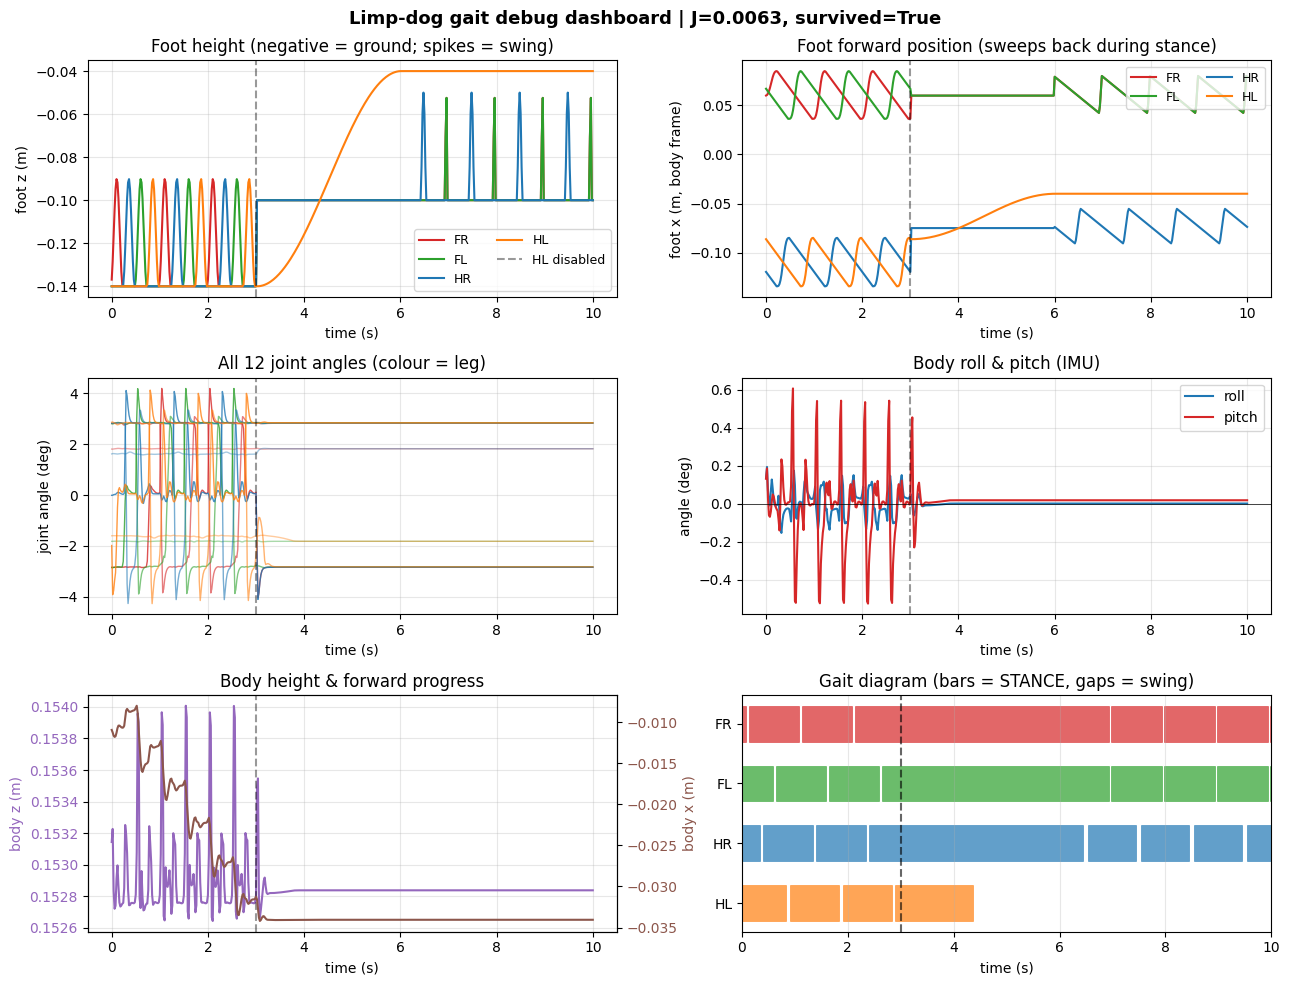


For your project report: right-click the plot to save it as PNG.


In [12]:
# ---- 11. Debug dashboard ----
import matplotlib.pyplot as plt

def run_with_telemetry(disabled_leg_name, velocity=0.05, trial_duration=10.0,
                       disable_at_t=3.0):
    """Run a trial and record everything for plotting."""
    bridge  = make_bridge(control_dt=DT)
    ctrl    = ThreeLegGaitController(dt=DT)
    metrics = MetricsLogger(vx_cmd=velocity, trial_duration=trial_duration)
    disabled_leg = LEG_MAP[disabled_leg_name.upper()]

    bridge.settle_to_stance(duration=2.0, dt=DT)
    metrics.start_trial()
    t_start = bridge.sim_t

    log = {
        "t": [], "foot_cmd": [], "joint_angles": [],
        "roll": [], "pitch": [], "body_z": [], "body_x": [],
        "phases": [], "limp_phase": [],
    }

    leg_disabled = False
    while (bridge.sim_t - t_start) < trial_duration:
        elapsed = bridge.sim_t - t_start
        if disabled_leg is not None and not leg_disabled and elapsed >= disable_at_t:
            ctrl.disable_leg(disabled_leg)
            leg_disabled = True

        foot_pos = ctrl.step(velocity=velocity)
        bridge.send_foot_positions(foot_pos, cmd_vx=velocity)
        s = bridge.get_state_dict()
        metrics.update(vx=s["vx"], vz=s["vz"], roll=s["roll"],
                       pitch=s["pitch"], body_height=s["body_height"],
                       sim_t=bridge.sim_t - t_start)

        # log
        log["t"].append(elapsed)
        log["foot_cmd"].append(foot_pos.copy())
        joint_angles = np.array([data.qpos[a] for a in bridge._joint_qpos_addr])
        log["joint_angles"].append(joint_angles)
        log["roll"].append(s["roll"])
        log["pitch"].append(s["pitch"])
        log["body_z"].append(s["body_height"])
        log["body_x"].append(float(data.qpos[0]))
        log["phases"].append(ctrl.phases.copy() if ctrl.disabled_leg is None else None)
        log["limp_phase"].append(ctrl.limp_phase if ctrl.disabled_leg is not None else None)

    return log, metrics.end_trial(bridge.sim_t - t_start)


print("Running instrumented limp-dog trial...")
log, result = run_with_telemetry("HL", velocity=0.05, trial_duration=10.0)
print(f"\nResult: J = {result['J']:.4f}, survived = {result['survived']}")

t = np.array(log["t"])
foot_cmd = np.array(log["foot_cmd"])  # (N, 4, 3)
joints = np.array(log["joint_angles"])  # (N, 12)

# ---- Plots ----
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
fig.suptitle(f"Limp-dog gait debug dashboard | J={result['J']:.4f}, "
             f"survived={result['survived']}", fontsize=13, fontweight="bold")

LEG_COLORS = ["#d62728", "#2ca02c", "#1f77b4", "#ff7f0e"]  # FR, FL, HR, HL
LEG_NAMES_PLOT = ["FR", "FL", "HR", "HL"]

# 1. Foot Z (swing/stance pattern)
ax = axes[0, 0]
for i in range(4):
    ax.plot(t, foot_cmd[:, i, 2], color=LEG_COLORS[i], label=LEG_NAMES_PLOT[i], lw=1.5)
ax.axvline(3.0, color="k", ls="--", alpha=0.4, label="HL disabled")
ax.set_xlabel("time (s)")
ax.set_ylabel("foot z (m)")
ax.set_title("Foot height (negative = ground; spikes = swing)")
ax.legend(loc="lower right", ncol=2, fontsize=9)
ax.grid(alpha=0.3)

# 2. Foot X (forward sweep)
ax = axes[0, 1]
for i in range(4):
    ax.plot(t, foot_cmd[:, i, 0], color=LEG_COLORS[i], label=LEG_NAMES_PLOT[i], lw=1.5)
ax.axvline(3.0, color="k", ls="--", alpha=0.4)
ax.set_xlabel("time (s)")
ax.set_ylabel("foot x (m, body frame)")
ax.set_title("Foot forward position (sweeps back during stance)")
ax.legend(loc="upper right", ncol=2, fontsize=9)
ax.grid(alpha=0.3)

# 3. Joint angles
ax = axes[1, 0]
JOINT_LABELS = [f"{n}_{j+1}" for n in ["FR", "FL", "BR", "BL"] for j in range(3)]
for i in range(12):
    leg = i // 3
    joint = i % 3
    ax.plot(t, np.degrees(joints[:, i]),
            color=LEG_COLORS[leg], lw=1.0, alpha=0.4 + 0.2 * joint)
ax.axvline(3.0, color="k", ls="--", alpha=0.4)
ax.set_xlabel("time (s)")
ax.set_ylabel("joint angle (deg)")
ax.set_title("All 12 joint angles (colour = leg)")
ax.grid(alpha=0.3)

# 4. Roll / pitch
ax = axes[1, 1]
ax.plot(t, np.degrees(log["roll"]),  color="#1f77b4", label="roll",  lw=1.5)
ax.plot(t, np.degrees(log["pitch"]), color="#d62728", label="pitch", lw=1.5)
ax.axhline(0, color="k", lw=0.5)
ax.axvline(3.0, color="k", ls="--", alpha=0.4)
ax.set_xlabel("time (s)")
ax.set_ylabel("angle (deg)")
ax.set_title("Body roll & pitch (IMU)")
ax.legend()
ax.grid(alpha=0.3)

# 5. Body height & forward progress
ax = axes[2, 0]
ax.plot(t, log["body_z"],  color="#9467bd", label="height (m)", lw=1.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("body z (m)", color="#9467bd")
ax.tick_params(axis="y", labelcolor="#9467bd")
ax.axvline(3.0, color="k", ls="--", alpha=0.4)
ax2 = ax.twinx()
ax2.plot(t, log["body_x"], color="#8c564b", label="forward (m)", lw=1.5)
ax2.set_ylabel("body x (m)", color="#8c564b")
ax2.tick_params(axis="y", labelcolor="#8c564b")
ax.set_title("Body height & forward progress")
ax.grid(alpha=0.3)

# 6. Gait diagram (stance = bar, swing = gap)
ax = axes[2, 1]
THRESH = -0.099  # foot is "in swing" if commanded z is above this
for i in range(4):
    in_swing = foot_cmd[:, i, 2] > THRESH
    # Find contiguous stance runs
    in_stance = ~in_swing
    # plot stance as bars
    starts, ends = [], []
    in_run = False
    for k, v in enumerate(in_stance):
        if v and not in_run:
            starts.append(t[k]); in_run = True
        elif not v and in_run:
            ends.append(t[k]); in_run = False
    if in_run:
        ends.append(t[-1])
    for s, e in zip(starts, ends):
        ax.barh(i, e - s, left=s, height=0.6,
                color=LEG_COLORS[i], alpha=0.7,
                edgecolor=LEG_COLORS[i], linewidth=0.5)
ax.axvline(3.0, color="k", ls="--", alpha=0.6)
ax.set_yticks(range(4))
ax.set_yticklabels(LEG_NAMES_PLOT)
ax.set_xlabel("time (s)")
ax.set_title("Gait diagram (bars = STANCE, gaps = swing)")
ax.set_xlim(0, t[-1])
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()
print("\nFor your project report: right-click the plot to save it as PNG.")
